In [2]:
# Code by Yug Saini
# Project Submitted under Guidance from Dr Rishi Asthana, Course : Linear Algebra and Differential Equations
# Image compression using Principal Component anaylsis
# Date : 11 Nov 2025

In [3]:
import cv2 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [4]:
img = cv2.cvtColor(cv2.imread("red_dice.jpg"), cv2.COLOR_BGR2RGB)

In [5]:
img.shape

(1336, 2546, 3)

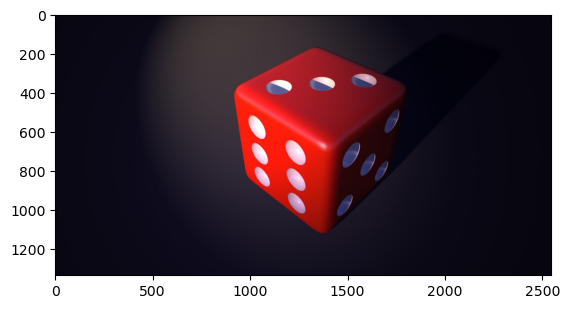

In [6]:
plt.imshow(img)

In [7]:
r, g, b = cv2.split(img)

In [8]:
r, g, b = r/255, g/255, b/255 # normalising them between 0 and 1


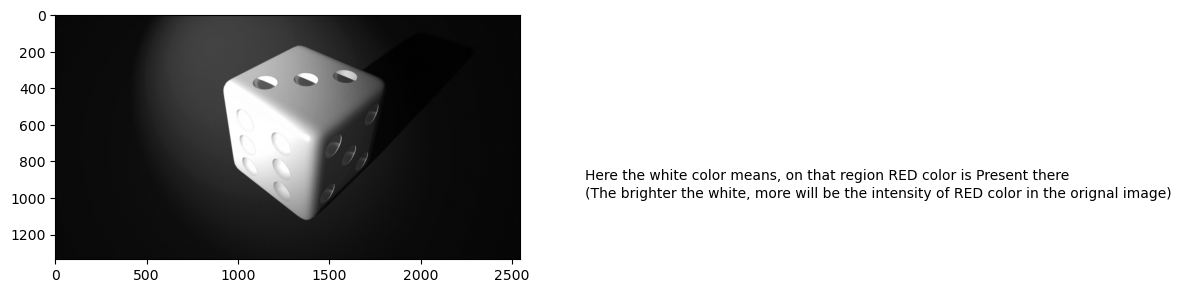

In [9]:
plt.figure(figsize = (6,10))
plt.imshow(r,cmap='gray')
plt.text(x = 2900, y = 900, s = "Here the white color means, on that region RED color is Present there")
plt.text(x = 2900, y = 1000, s = "(The brighter the white, more will be the intensity of RED color in the orignal image)")
plt.show()

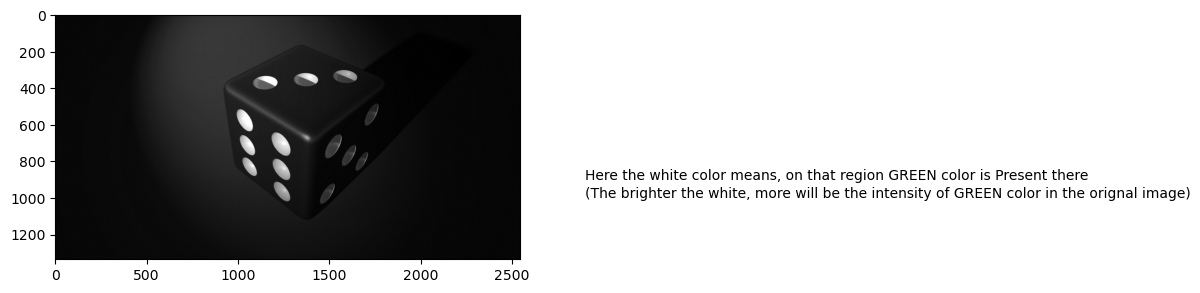

In [10]:
plt.figure(figsize = (6,10))
plt.imshow(g,cmap = 'gray')
plt.text(x = 2900, y = 900, s = "Here the white color means, on that region GREEN color is Present there")
plt.text(x = 2900, y = 1000, s = "(The brighter the white, more will be the intensity of GREEN color in the orignal image)")
plt.show();

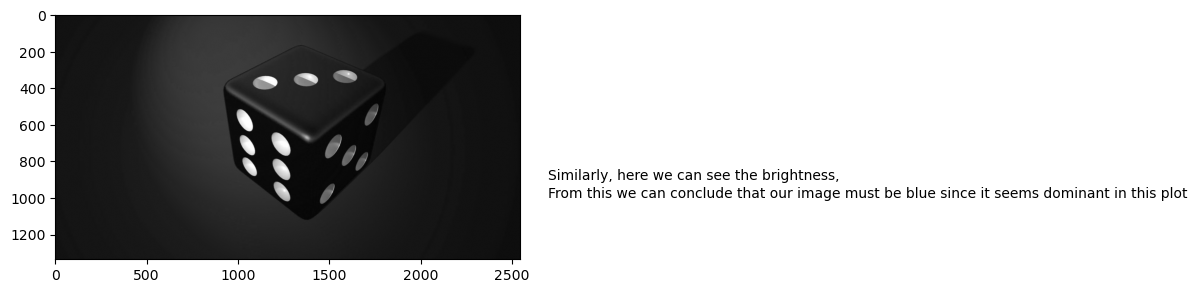

In [11]:
plt.figure(figsize = (6,10))
plt.imshow(b, cmap= 'gray')
plt.text(x = 2700, y = 900, s = "Similarly, here we can see the brightness,")
plt.text(x = 2700, y = 1000, s = "From this we can conclude that our image must be blue since it seems dominant in this plot")
plt.show()

In [12]:
r.shape
# previous 

(1336, 2546)

In [13]:
r[:5:]
r[0][1]

np.float64(0.03137254901960784)

In [14]:
pca_components = 25
pca_r =PCA(n_components = pca_components)
reduced_r = pca_r.fit_transform(r)

In [15]:
reduced_r.shape

(1336, 25)

In [16]:
# similarly using pca on green
pca_g =PCA(n_components = pca_components)
reduced_g = pca_g.fit_transform(g)
 # and blue
pca_b =PCA(n_components = pca_components)
reduced_b = pca_b.fit_transform(b)

In [17]:
combined = np.array([reduced_r, reduced_g, reduced_b])
combined.shape

(3, 1336, 25)

In [18]:
reconstructed_r = pca_r.inverse_transform(reduced_r)
reconstructed_g = pca_g.inverse_transform(reduced_g)
reconstructed_b = pca_b.inverse_transform(reduced_b)

In [19]:
img_reconstructed = (cv2.merge((reconstructed_r,reconstructed_g,reconstructed_b)))
img_reconstructed.shape
# this has the orignal shape

(1336, 2546, 3)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.16496019150104574..1.1540301092366465].


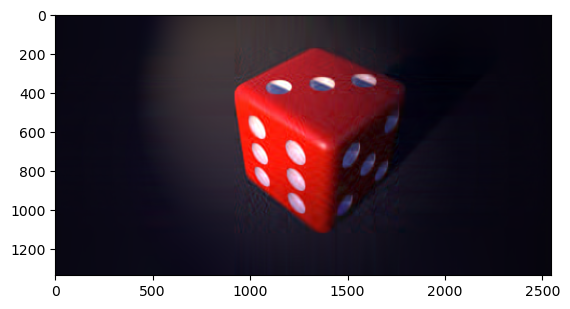

In [20]:
plt.imshow(img_reconstructed)

In [21]:
def pca_im(img, k):
    img = img/255.0
    r, g, b = cv2.split(img)
    pca_components = k
    pca_r =PCA(n_components = pca_components)
    reduced_r = pca_r.fit_transform(r)
    pca_g =PCA(n_components = pca_components)
    reduced_g = pca_g.fit_transform(g)
    pca_b =PCA(n_components = pca_components)
    reduced_b = pca_b.fit_transform(b)
    reconstructed_r = pca_r.inverse_transform(reduced_r)
    reconstructed_g = pca_g.inverse_transform(reduced_g)
    reconstructed_b = pca_b.inverse_transform(reduced_b)
    img_reconstructed = (cv2.merge((reconstructed_r,reconstructed_g,reconstructed_b)))
    return img_reconstructed

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.10997475584097233..1.0966025641807724].


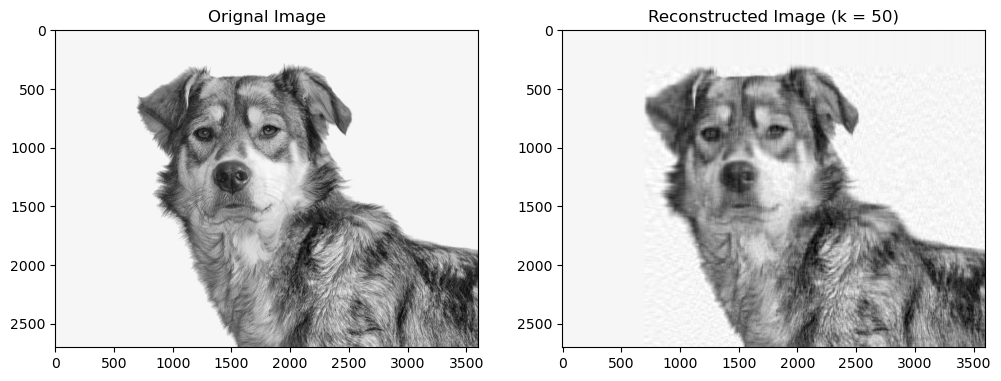

In [22]:
img2 = cv2.cvtColor(cv2.imread("dog.jpg"), cv2.COLOR_BGR2RGB)
im2_reconstructed = pca_im(img2,50)
plt.figure(figsize = (12,5))
plt.subplot(1,2,1)
plt.imshow(img2)
plt.title("Orignal Image")

plt.subplot(1,2,2)
plt.imshow(im2_reconstructed)
plt.title("Reconstructed Image (k = 50)")
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.10999720285606396..1.1415811573204588].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.16306152219106207..1.1176252974128973].


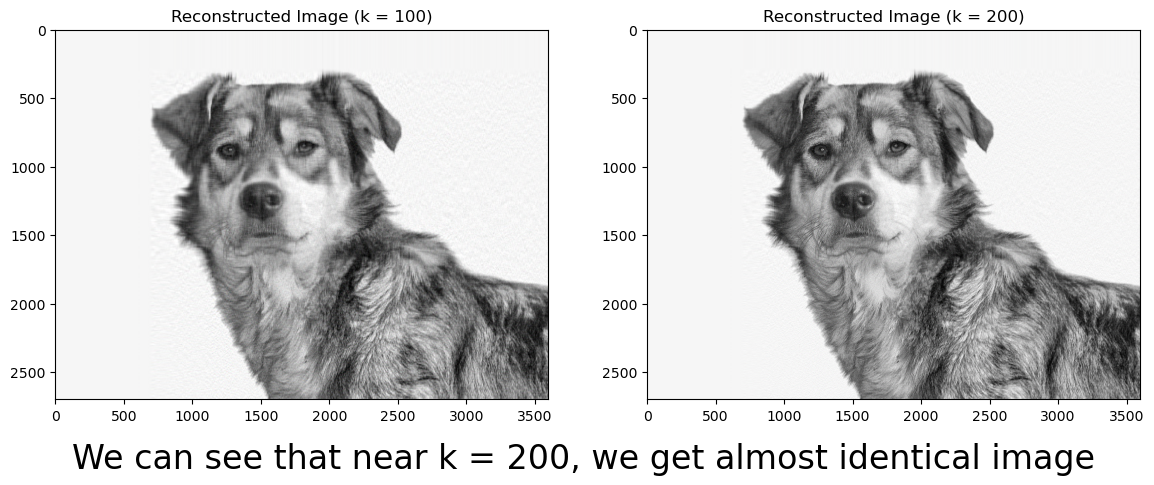

In [23]:
im2_reconstructed_100 = pca_im(img2,100)
im2_reconstructed_200 = pca_im(img2,200)
plt.figure(figsize = (14,5))
plt.subplot(1,2,1)
plt.imshow(im2_reconstructed_100)
plt.title("Reconstructed Image (k = 100)")

plt.subplot(1,2,2)
plt.imshow(im2_reconstructed_200)
plt.title("Reconstructed Image (k = 200)")
plt.text(x = -4200, y = 3200,fontsize = 24 ,s= "We can see that near k = 200, we get almost identical image")
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.15314873882298918..1.0591185226690327].


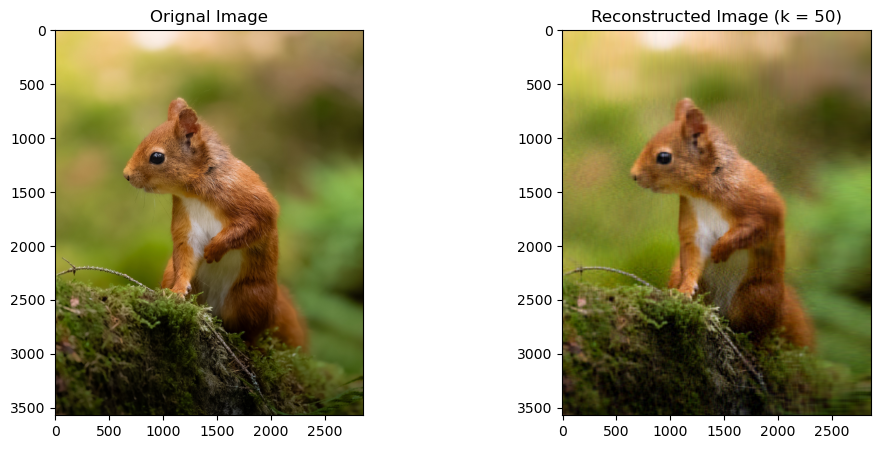

In [24]:
# lets try on somehting more colourfull
img3 = cv2.cvtColor(cv2.imread("squirrel.jpg"), cv2.COLOR_BGR2RGB)
im3_reconstructed = pca_im(img3,50)
plt.figure(figsize = (12,5))
plt.subplot(1,2,1)
plt.imshow(img3)
plt.title("Orignal Image")

plt.subplot(1,2,2)
plt.imshow(im3_reconstructed)
plt.title("Reconstructed Image (k = 50)")
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.22486835734239924..1.247131004368778].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.21789329646938896..1.2422796658387423].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2028028787384126..1.2516620978537327].


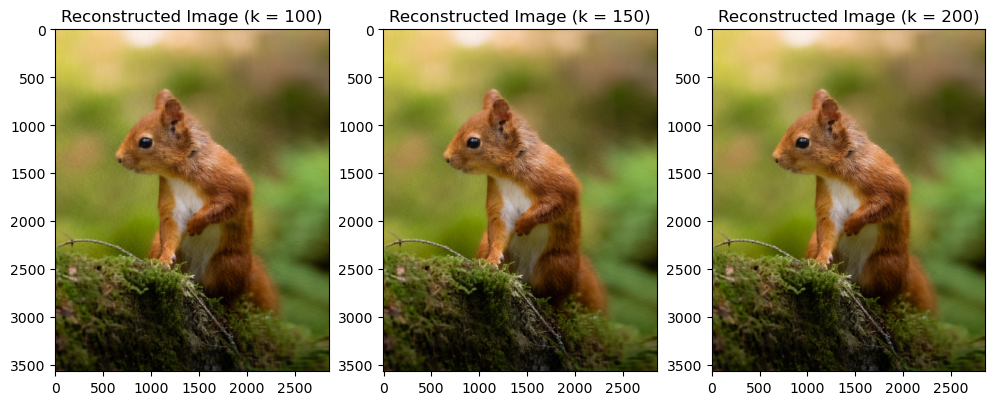

In [25]:
im3_reconstructed_100 = pca_im(img3,100)
im3_reconstructed_150 = pca_im(img3,150)
im3_reconstructed_200 = pca_im(img3,200)
plt.figure(figsize = (12,5))
plt.subplot(1,3,1)
plt.imshow(im3_reconstructed_100)
plt.title("Reconstructed Image (k = 100)")

plt.subplot(1,3,2)
plt.imshow(im3_reconstructed_150)
plt.title("Reconstructed Image (k = 150)")

plt.subplot(1,3,3)
plt.imshow(im3_reconstructed_200)
plt.title("Reconstructed Image (k = 200)")
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.42665916807929194..1.3637658329479043].


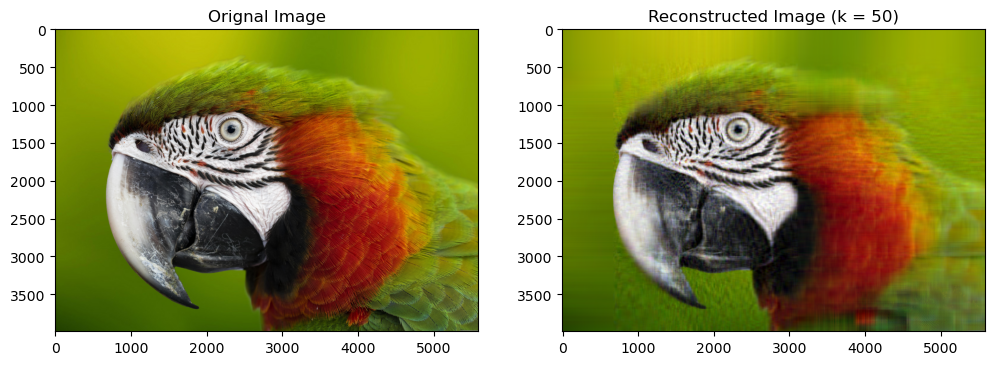

In [26]:
# lets try on somehting more colourfull
img4 = cv2.cvtColor(cv2.imread("macawjpg.jpg"), cv2.COLOR_BGR2RGB)
im4_reconstructed = pca_im(img4,50)
plt.figure(figsize = (12,5))
plt.subplot(1,2,1)
plt.imshow(img4)
plt.title("Orignal Image")

plt.subplot(1,2,2)
plt.imshow(im4_reconstructed)
plt.title("Reconstructed Image (k = 50)")
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.40389675358146093..1.4083130427425372].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.45199340289335166..1.3494791186288135].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.46001492346170353..1.2829129351157147].


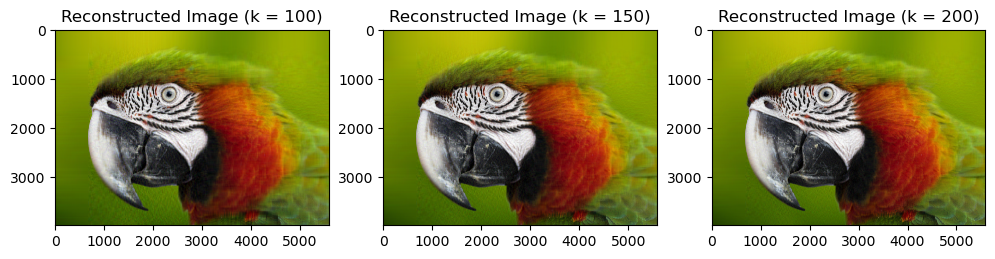

In [27]:
im4_reconstructed_100 = pca_im(img4,100)
im4_reconstructed_150 = pca_im(img4,150)
im4_reconstructed_200 = pca_im(img4,200)
plt.figure(figsize = (12,5))
plt.subplot(1,3,1)
plt.imshow(im4_reconstructed_100)
plt.title("Reconstructed Image (k = 100)")

plt.subplot(1,3,2)
plt.imshow(im4_reconstructed_150)
plt.title("Reconstructed Image (k = 150)")

plt.subplot(1,3,3)
plt.imshow(im4_reconstructed_200)
plt.title("Reconstructed Image (k = 200)")
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.3737683984969179..1.2367818122291203].


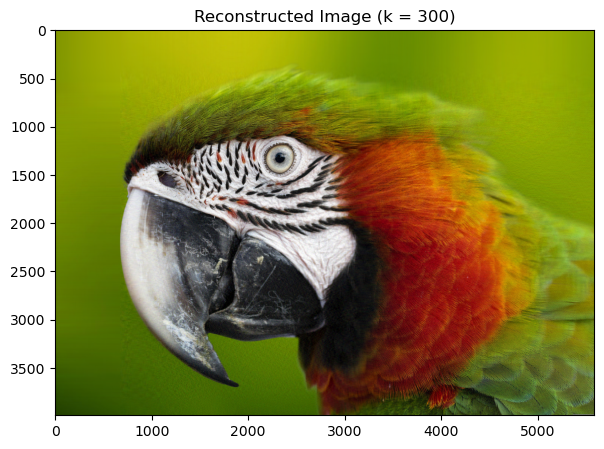

In [28]:
im4_reconstructed_300 = pca_im(img4,300)
plt.figure(figsize = (12,5))
plt.imshow(im4_reconstructed_300)
plt.title("Reconstructed Image (k = 300)")
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.3417516683980076..1.2418078217202373].


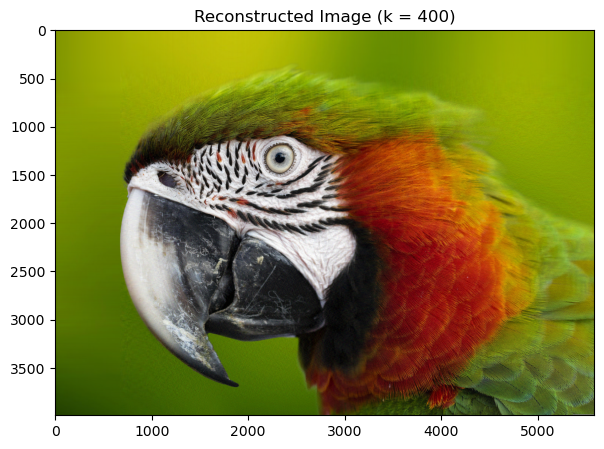

In [29]:
im4_reconstructed_400 = pca_im(img4,400)
plt.figure(figsize = (12,5))
plt.imshow(im4_reconstructed_400)
plt.title("Reconstructed Image (k = 400)")
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.20416463758661774..1.1834470969850581].


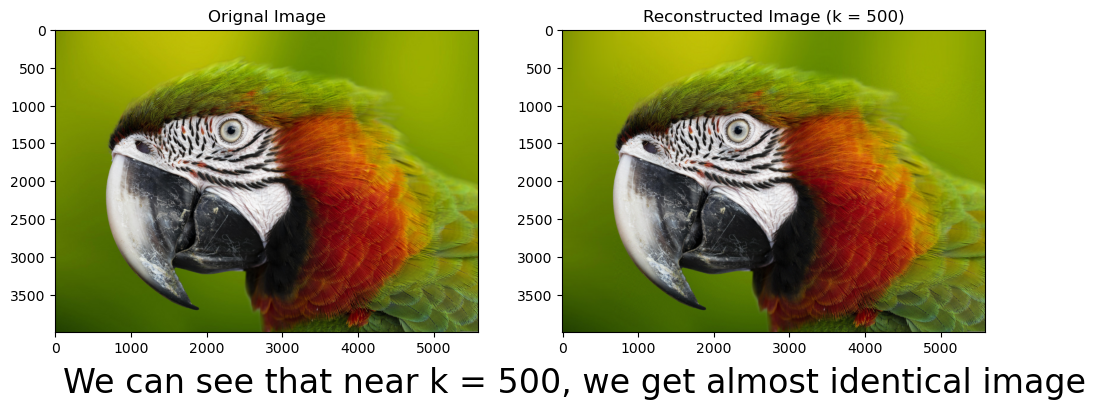

In [36]:
im4_reconstructed_500 = pca_im(img4,800)

plt.figure(figsize = (12,5))
plt.subplot(1,2,1)
plt.imshow(img4)
plt.title("Orignal Image")

plt.subplot(1,2,2)
plt.imshow(im4_reconstructed_500)
plt.title("Reconstructed Image (k = 500)")
plt.text(x = -6600, y = 4800,fontsize = 24 ,s= "We can see that near k = 500, we get almost identical image")
plt.show()